In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt
import time 
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.layers import create_layers, update_from_arrays
from src.plot.plot_tools import plot_1d_profile, plot_layered_config
from src.config import Config
from src.builders import build_problem
from src.noise import add_noise
from src.layers import create_layers_from_interfaces
from src.misfit import l2_misfit
from src.plot.plot_tools import create_plot

In [2]:
config = Config(n_receivers=16, x_min=0., x_max=1500.,
                   z_rec=75., z_src=70., x_src=50., nq_prop=128, f0=10.,
                   total_time=1.024, delay=0.15, epsilon=1.5, free_surface=False, nfft_pad_factor=4)
param, acq = build_problem(config)

In [22]:
vps = np.array([1500.0, 3000.0, 1800.0, 3500.0])
vp_ref = np.array([vps[2], vps[3]])
z_int = np.array([0.0, 100.0, 250.0, 400., 700.])
rhos = np.array([1200.0, 2100.0, 2000.0, 2200.0])

layers = create_layers_from_interfaces(z_int, vps, rhos)

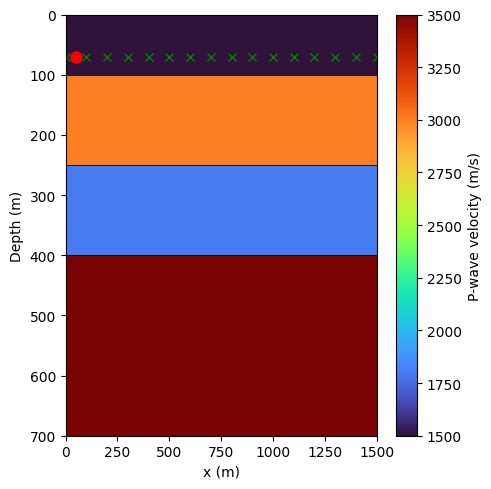

In [23]:
plot_layered_config(layers, xrecvs=acq.xr, zrecvs=config.z_src, xs=[config.x_src, config.z_src], param='vp', cmap='turbo')

In [5]:
# generate observations
d_obs, _ = forward(layers, config, timing=True)
d_obs_noise, std_noise = add_noise(d_obs, noise_level=0.1)

Sommerfeld quadrature elapsed: 6.40 s


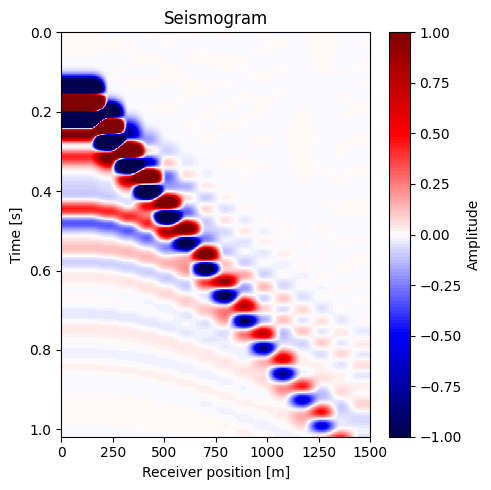

In [11]:
from src.plot.plot_tools import plot_seismogram
plot_seismogram(d_obs[0].T, acq.xr, param.time, vmin=-1., vmax=1., ncolors=128, figsize=(5,5))

In [7]:
L2_Err = l2_misfit(d_obs_noise, d_obs, std_noise=std_noise)
print("misfit total = ", L2_Err)

misfit total =  1280.418863107535


In [8]:
vp_min, vp_max, npts = 500, 5000, 50
vp_min2, vp_max2 = 500, 5000

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        VP = np.array([vps[0], vps[1], point[0], point[1]])
        layers = update_from_arrays(layers, vps=VP)
        d_cal, _ = forward(layers, config, timing=False)
        COST[i,j] = l2_misfit(d_cal, d_obs)

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 205.175 seconds.
time per forward is 0.082 seconds.


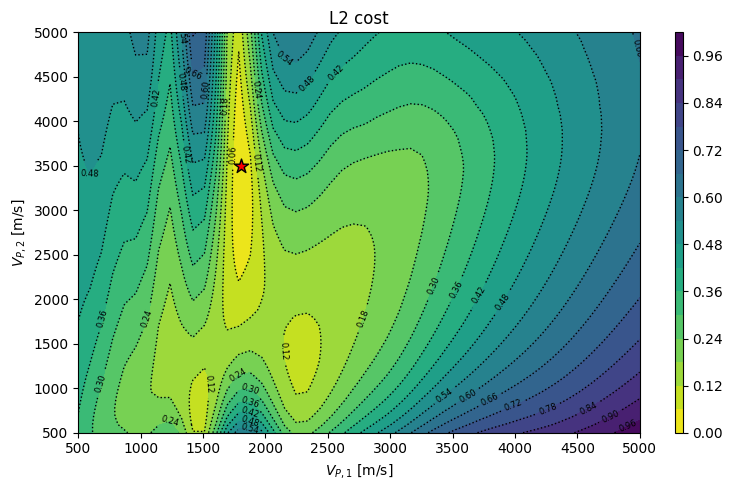

In [9]:
create_plot(xgrid, ygrid, COST/np.max(COST), vps[2], vps[3], vmin=vp_min, vmax=vp_max, title='L2 cost')